# Slow farmer Kolmogorov equations
This is complex enough that it deserves its own notebook

In [147]:
import matplotlib as mpl
from matplotlib import pyplot as plt
import scipy as sp
import numpy as np

import pickle
import time

In [148]:
#set serif font
plt.rcParams["font.family"]="serif"
plt.rcParams["mathtext.fontset"]="dejavuserif"

In [149]:
#colorblind optimized color cycle
#https://doi.org/10.1038/nmeth.1618
wong_colors = ["#000000", "#E69F00",
               "#56B4e9", "#009E73",
               "#F0E442", "#0072B2",
               "#D55E00", "#CC79A7"]
wong_cycle = mpl.rcsetup.cycler(color=wong_colors)

In [150]:
R = 0.00888
K = 0.00772

## setting up system

In [167]:
def timeToIndex(ar, t):
    """given array of times, ar, returns the largest index i such that ar[i]<t"""

    if ar[-1] < t:
        raise IndexError("Time t is out of bounds of array ar")
        
    i = 0
    while ar[i+1] <= t:
        i += 1
    return i

In [151]:
def growthRate(Ng, N, A):
    return K*Ng*(1-Ng/A)

def eatRate(Ng, N, A):
    return N*R*Ng/A

In [152]:
#s matrix elements

def s_ijkl(i, j, k, l, N, A):

    if i == k and j == l:
        return -growthRate(i, N, A) - eatRate(i, N, A)
    elif i == k-1 and j == l:
        return growthRate(k-1, N, A)
    elif i == k+1 and j == l:
        return eatRate(k+1, N, A)*l/N
    elif i == k+1 and j == l-1:
        return eatRate(k+1, N, A)*(N-l+1)/N
    else:
        return 0

In [153]:
def sMatrix(N, A):
    s_matrix = np.zeros((A+1, N+1, A+1, N+1))
    for i in range(A+1):
        for j in range(N+1):
            for k in range(A+1):
                for l in range(N+1):
                    s_matrix[i,j,k,l] = s_ijkl(i, j, k, l, N, A)
    return s_matrix

In [154]:
def sFlatten(s):
    """accepts matrix of shape (A+1, N+1, A+1, N+1)
    reshape into matrix of shape ( (A+1)(N+1), (A+1)(N+1) )
    does not need N and A passed to it because dimensions can be grabbed
    from s.shape
    """

    #dim = (A+1)(N+1)
    dim = s.shape[0]*s.shape[1]

    #fortran order
    return np.reshape(s, (dim, dim), "f")

def qFlatten(q):
    """accepts matrix of shape (A+1, N+1)
    reshape into matrix of shape (A+1)*(N+1)
    """

    dim = q.shape[0]*q.shape[1]

    return np.reshape(q, (dim), "f")

def qExpand(q, N, A):
    """accepts q vector of shape (A+1)*(N+1)
    reshape into matrix (A+1, N+1)
    needs N and A passed to it
    """

    return np.reshape(q, (A+1, N+1), "f")

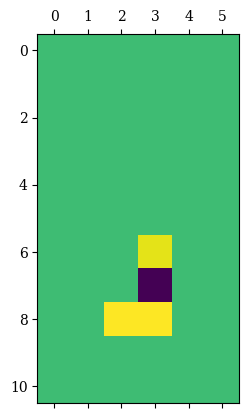

In [155]:
f, ax = plt.subplots()

ax.matshow(sMatrix(5, 10)[:, :, 7, 3])

## quasi-equilibrium distribution
used for initial condition for slow farmer

In [156]:
def quasiEqRec(A, N):
    mat = np.zeros((A, A))
    for i in range(1, A):
        #each loop inserts equation p_i+1 mu_i+1 - p_i lambda_i = 0
        mat[i-1, i] = eatRate(i+1, N, A)
        mat[i-1, i-1] = -growthRate(i, N, A)

    #final row for probability=1 equation
    for i in range(0, A):
        mat[-1, i] = 1

    #dependent variable vector
    b = np.zeros(A)
    b[-1]=1

    #concatenate a zero to the beginning to represent p_0=0
    #important for use with pmfE() and pmfVar(), which assume that p_i appears at index i
    return np.concatenate((np.array([0]), np.linalg.solve(mat, b)))

## setting up simulation

In [222]:
def simulate(N, A, stoptime):

    s_matrix = sMatrix(N, A)

    q0 = np.zeros((A+1, N+1))
    #begin pasture Nw=0
    #and Ng is quasi-equilibrium
    #meaning q_x,0 = p_x at equilibrium
    q0[:,0]=quasiEqRec(A, N)

    #need to reshape to work with solve_ivp
    #fortran order - first index changes fastest
    s_matrix = sFlatten(s_matrix)
    q0 = np.reshape(q0, ((N+1)*(A+1)), order="F")

    def sys(t, y):
        return np.matmul(y, s_matrix)

    st = time.time()

    s = sp.integrate.solve_ivp(sys, (0, stoptime), q0, method="RK23")
    print("finished in {0} seconds".format(time.time()-st))

    return s

In [223]:
sol = simulate(20, 50, 3600)

finished in 0.8171863555908203 seconds


## 3d plot

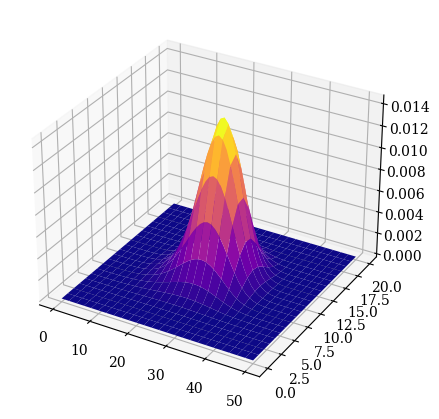

In [214]:
f, ax = plt.subplots(subplot_kw={"projection": "3d"}, layout="constrained", figsize=(4, 4))

Ng = np.arange(0, 51)
Nw = np.arange(0, 21)

Nw, Ng = np.meshgrid(Nw, Ng)

ax.plot_surface(Ng, Nw, qExpand(sol["y"][:,timeToIndex(sol["t"], 170)], 20, 50), cmap="plasma")

plt.show()

## heatmap plot

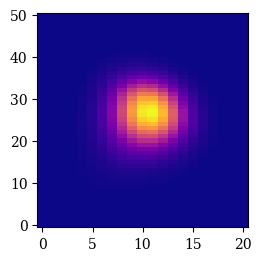

In [224]:
f, ax = plt.subplots(layout="constrained", figsize=(2.5, 2.5))

ax.imshow(qExpand(sol["y"][:,timeToIndex(sol["t"], 170)], 20, 50), origin="lower", aspect="auto", cmap="plasma")

plt.show()

In [ ]:
with open("slow_sol_20.dat", "rb") as f:
    sol_20 = pickle.load(f)

with open("slow_sol_100.dat", "rb") as f:
    sol_100 = pickle.load(f)

## plot evolution of q
for A=100 and N=40, plot evolution of q

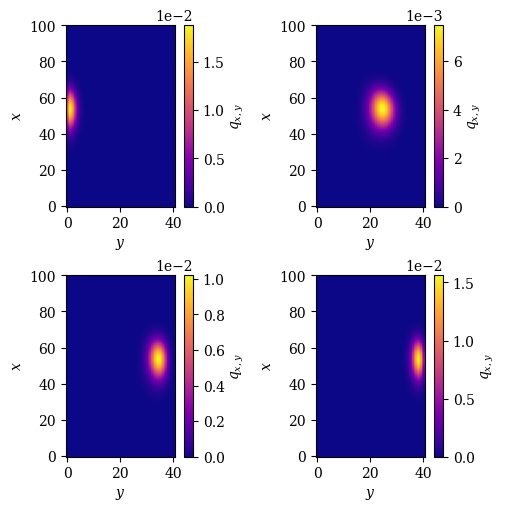

In [255]:
f, axs = plt.subplots(nrows=2, ncols=2, figsize=(5, 5), layout="constrained")

axs = np.reshape(axs, 4)

for i in range(0,4):
    data = qExpand(sol_100["40"]["y"][
                   :,timeToIndex(
                       sol_100["40"]["t"], [10, 200, 400, 600][i])], 40, 100)
    
    im_ptr = axs[i].imshow(data, origin="lower", aspect="auto", cmap="plasma")

    #negative pad is necessary to remove excess whitespace caused by power label
    cb = plt.colorbar(im_ptr, ax=axs[i], label="$q_{x,y}$", pad=-0.25)
    cb.formatter.set_powerlimits((-1, 5))
    axs[i].set_xticks([0, 20, 40])
    axs[i].set_xlabel("$y$")
    axs[i].set_ylabel("$x$")

plt.show()